# Skills Comparison for Faster- and Slower-Growing Occupations

> **Status: Work in progress.**  
> The overall comparison is working, but the skill-grouping method is **not final yet**. The main issue still being tested is the right balance between **broad skill categories** that are easy to interpret and **specific Lightcast skills** that are more actionable but can become too detailed.

## What this analysis is testing

The goal is to compare the skills employers currently request for occupations that are projected to grow faster versus occupations projected to grow more slowly.

The analysis is run separately for:

- **Short-term growth:** 2025–2027
- **Long-term growth:** 2024–2034

The projection data determine which occupations are considered faster- or slower-growing. **2025 Lightcast job postings** are then used to describe the skills currently requested for those occupations.

## Current methodology

1. **Define occupations by sector.**  
   Occupations are connected to the target industries using staffing-pattern data.

2. **Rank occupations by projected growth.**  
   Within each sector, the code identifies the faster-growing and slower-growing occupations using projected percentage employment growth.

3. **Match those occupations to 2025 Lightcast postings.**  
   Skills are pulled from the Lightcast skill and software-skill fields. Duplicate mentions of the same skill within a posting are removed.

4. **Compare skill prevalence.**  
   The code calculates the share of postings that mention each skill or skill category for the faster-growing versus slower-growing occupation groups.

## Skill grouping is still being refined

The code currently looks at skills in two ways:

- **Broad categories** such as Programming, Communication, Analytical, Operations, Healthcare, and Management.
- **Specific Lightcast skills** such as Python, SQL, patient care, inventory management, or project management.

Broad categories make the figure easier to read but can hide useful detail. Specific skills are more actionable but can become too fragmented. The final manuscript version may use a combination of both.

## Important interpretation

This analysis does **not** identify “future skills” directly. It asks:

**Do occupations projected to grow faster currently show a different skill profile in 2025 job postings than occupations projected to grow more slowly?**

The results are descriptive and should not be interpreted as evidence that a skill causes an occupation to grow.


## Short-Term Comparison: 2025–2027

This section ranks occupations using the short-term employment projections and compares 2025 job-posting skills for the faster- and slower-growing occupation groups.



STEP 1: STAFFING PATTERN — NAICS TO SOC
Healthcare: 373 detailed SOCs from NAICS prefixes ['62']
Manufacturing: 378 detailed SOCs from NAICS prefixes ['31', '32', '33']
Semiconductors: 184 detailed SOCs from NAICS prefixes ['334']

STEP 2: OCCUPATION PROJECTIONS

Projection table selected from occ_short_term (6).xlsx: sheet='OCC_Proj_ALL_25_27', header row=3
Columns: ['Area', 'SOC Code2', 'Occupation Title', '2025 Estimate3', '2027 Projection', 'Numeric4', 'Percent', 'Due to Growth', 'Due to Transfers5', 'Due to Exits6', 'Total7']

Projection table selected from ltop-04-2024to2034 (7).xlsx: sheet='Occupation_Projections_24_34', header row=2
Columns: ['Area Name', 'SOC Code1 ', ' Standard Occupation Classification (SOC)2 Title', '2024 Employment Estimates3', '2034 Employment Projections', '10 Year Numeric Change4', '10 Year Percentage Change', '10 Year Annualized Percentage Change', '10 year Openings Due to Exits5', '10 Year Openings Due to Transfers6', '10 Year Openings Due to Growth'

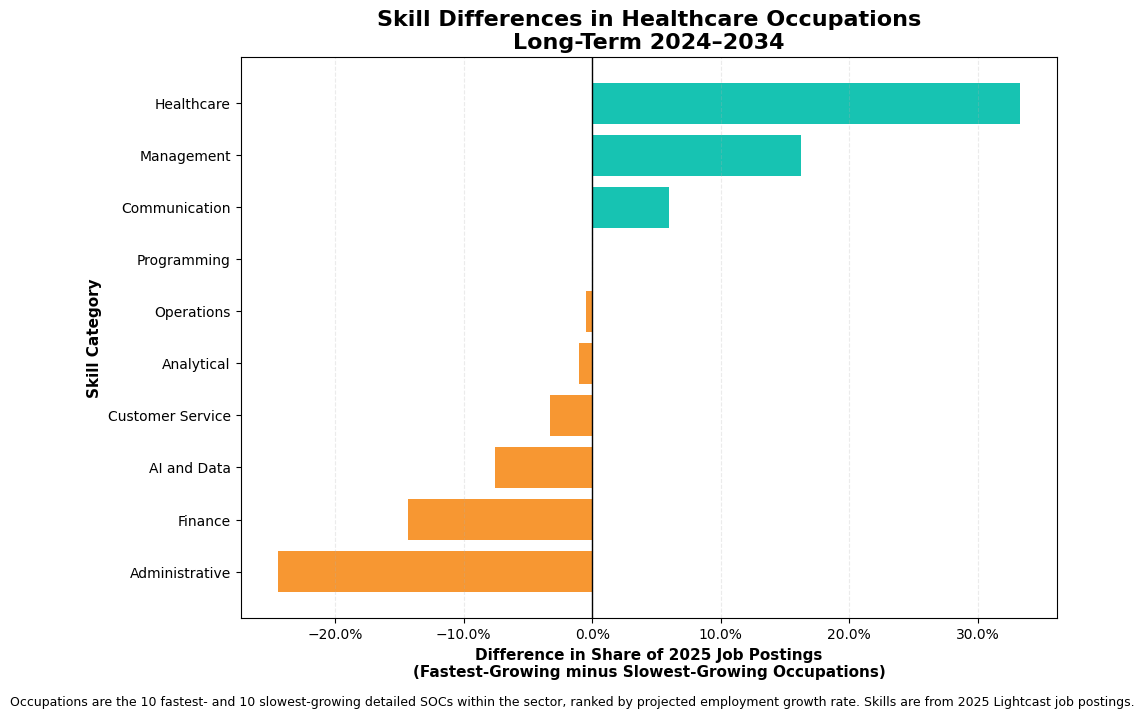


Healthcare | Long-Term 2024–2034
Fastest-growing postings: 6,008
Slowest-growing postings: 920
  Skill_Category Fastest_Growing_Posting_Share Slowest_Growing_Posting_Share Difference_Fast_Minus_Slow
      Healthcare                         37.2%                          3.9%                     +33.3%
      Management                         55.3%                         39.0%                     +16.3%
   Communication                         58.7%                         52.7%                      +6.0%
     Programming                         24.3%                         24.3%                      -0.0%
      Operations                         24.0%                         24.5%                      -0.5%
      Analytical                         36.9%                         37.9%                      -1.1%
Customer Service                         29.5%                         32.7%                      -3.3%
     AI and Data                         38.2%                         4

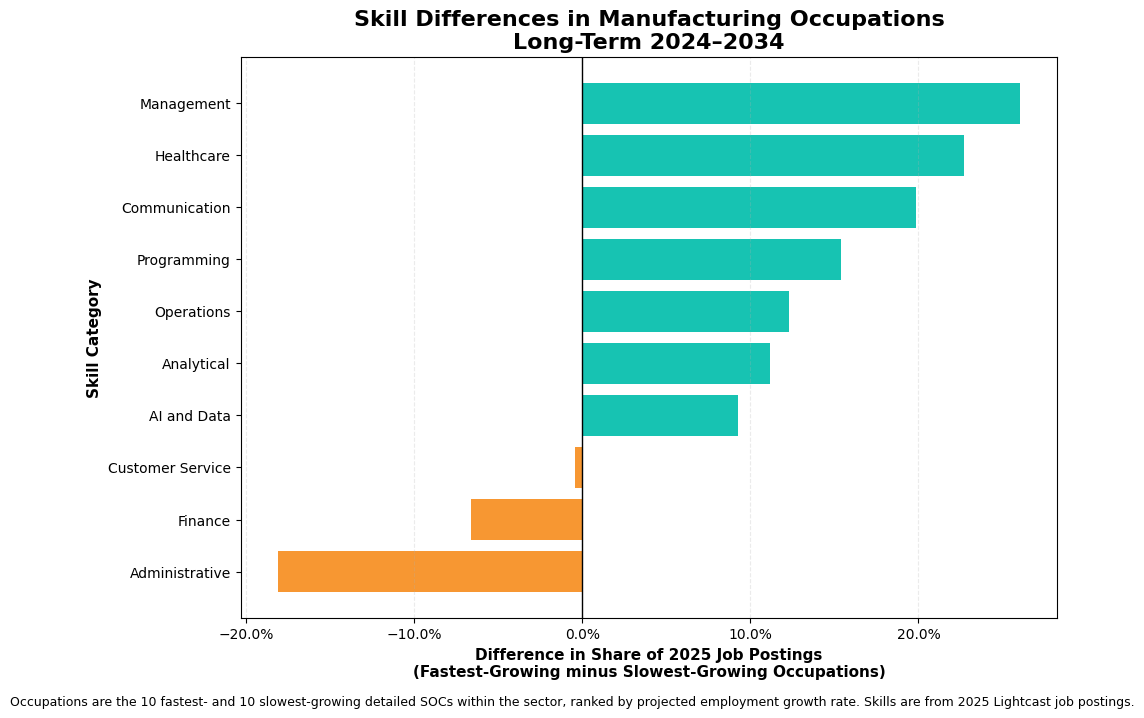


Manufacturing | Long-Term 2024–2034
Fastest-growing postings: 4,371
Slowest-growing postings: 826
  Skill_Category Fastest_Growing_Posting_Share Slowest_Growing_Posting_Share Difference_Fast_Minus_Slow
      Management                         63.5%                         37.4%                     +26.1%
      Healthcare                         25.5%                          2.8%                     +22.7%
   Communication                         71.2%                         51.3%                     +19.9%
     Programming                         32.4%                         17.1%                     +15.4%
      Operations                         42.6%                         30.3%                     +12.3%
      Analytical                         51.2%                         40.1%                     +11.2%
     AI and Data                         53.5%                         44.2%                      +9.3%
Customer Service                         39.7%                       

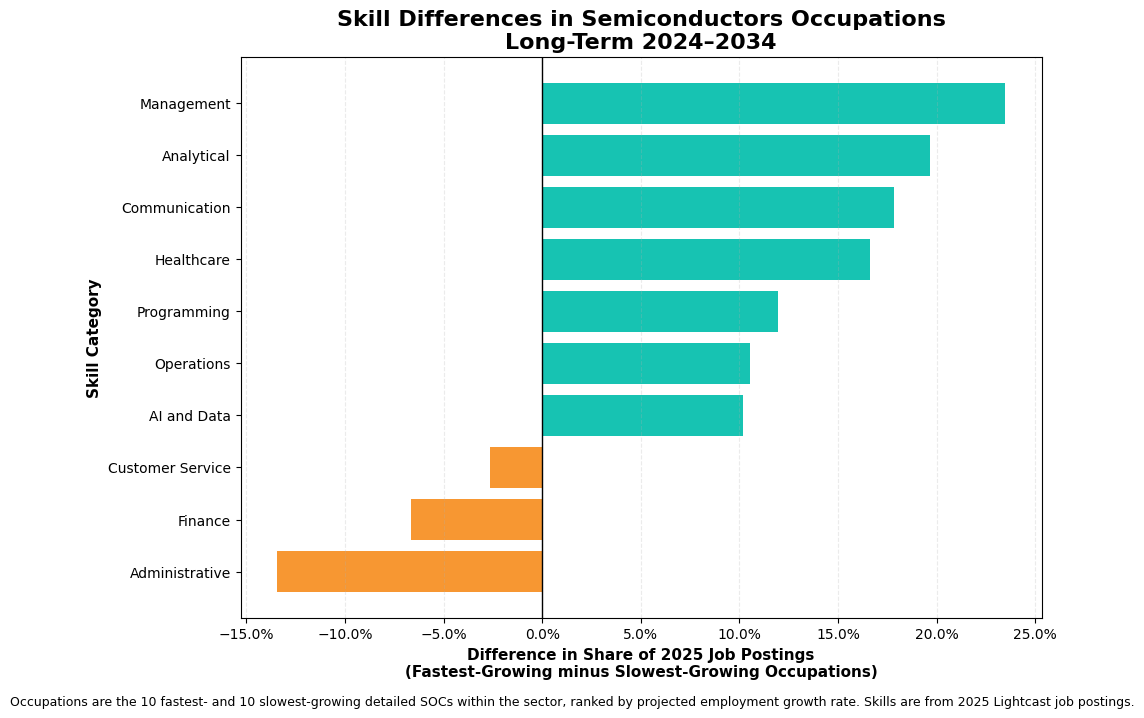


Semiconductors | Long-Term 2024–2034
Fastest-growing postings: 6,133
Slowest-growing postings: 1,256
  Skill_Category Fastest_Growing_Posting_Share Slowest_Growing_Posting_Share Difference_Fast_Minus_Slow
      Management                         57.7%                         34.2%                     +23.5%
      Analytical                         55.3%                         35.7%                     +19.7%
   Communication                         68.2%                         50.4%                     +17.8%
      Healthcare                         18.8%                          2.1%                     +16.6%
     Programming                         28.1%                         16.2%                     +11.9%
      Operations                         42.2%                         31.7%                     +10.5%
     AI and Data                         54.4%                         44.2%                     +10.2%
Customer Service                         34.1%                    

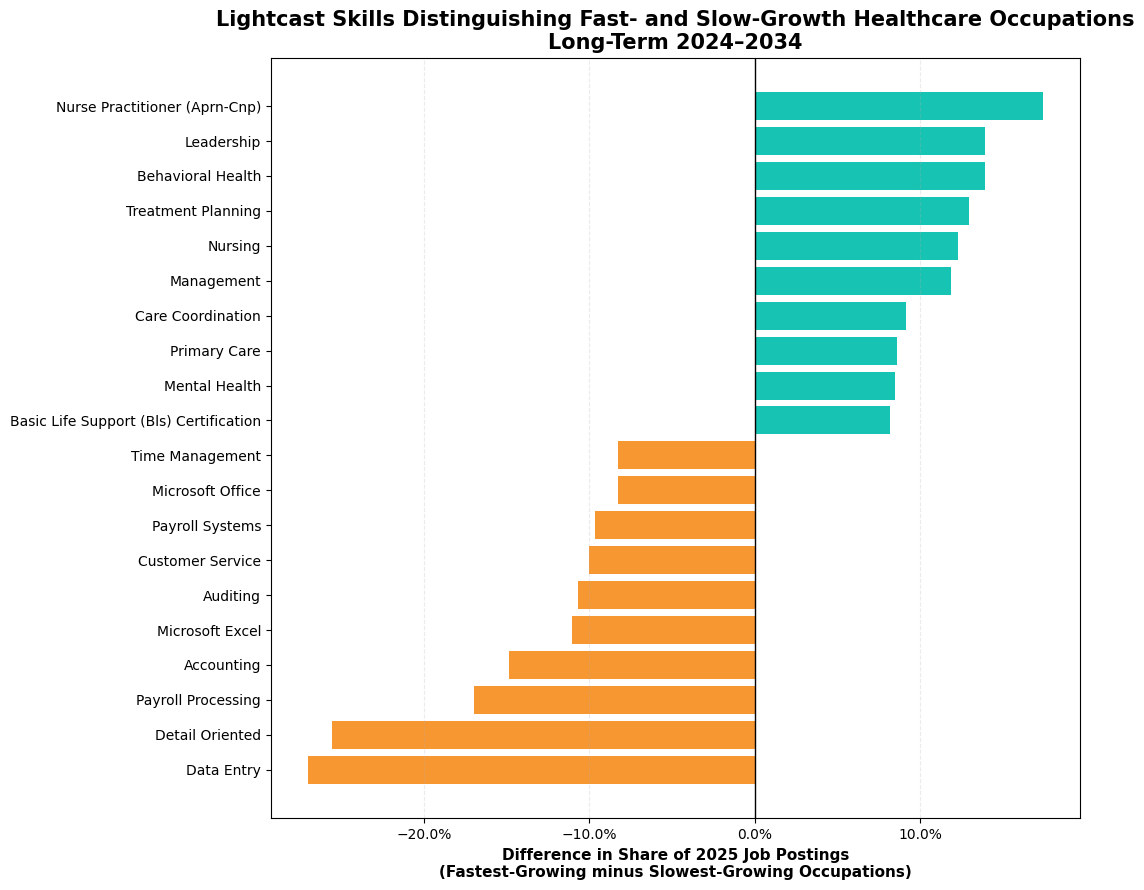

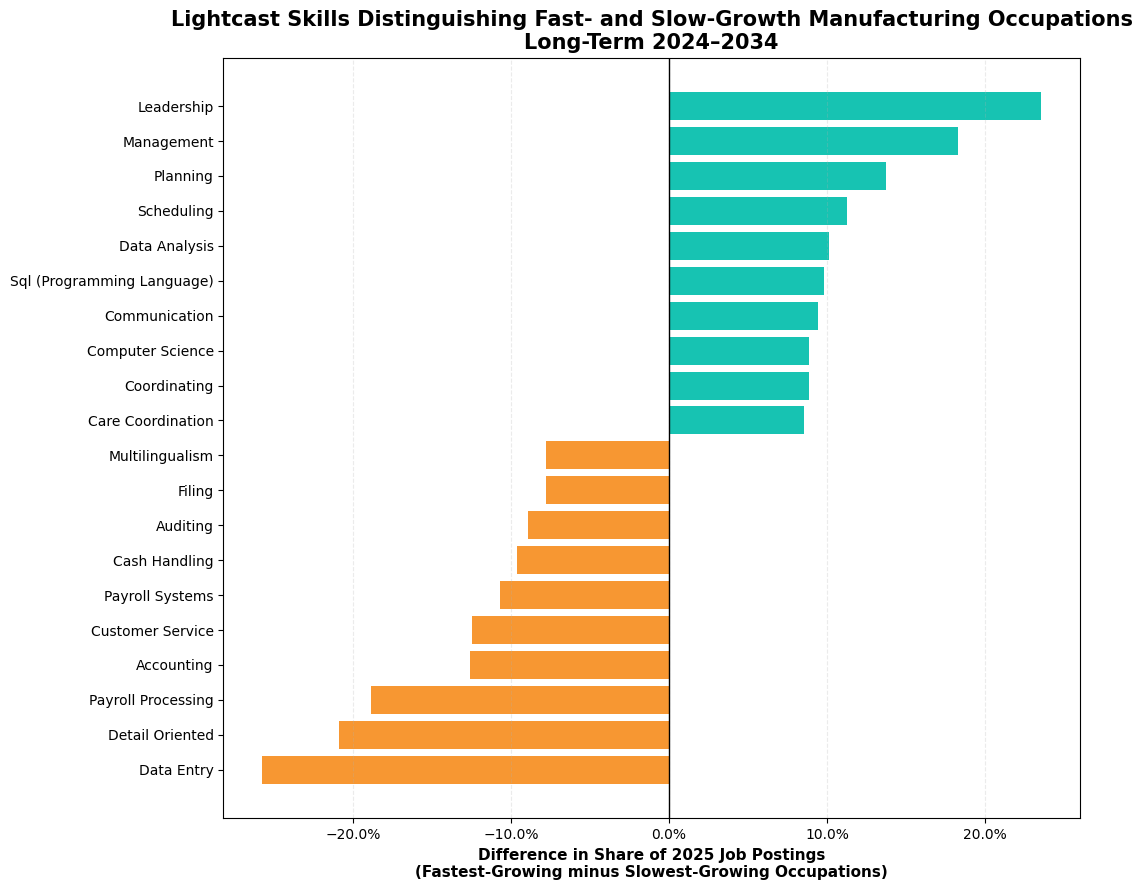

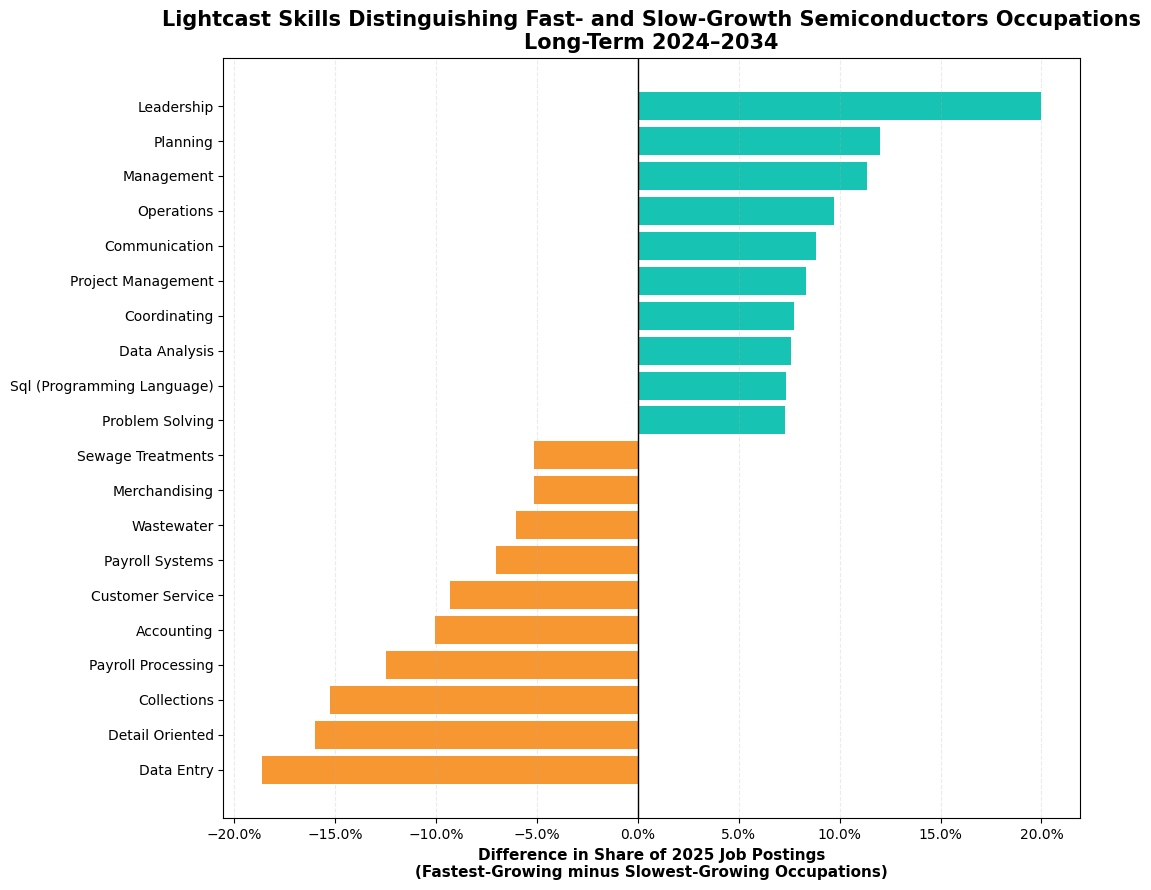


STEP 7: WRITE COMBINED REVIEW WORKBOOK

DONE.
All outputs saved to:
C:\Users\301533\Documents\Walmart_Analysis_Output\Sector_Skills_Analysis

Combined review workbook:
C:\Users\301533\Documents\Walmart_Analysis_Output\Sector_Skills_Analysis\Walmart_Sector_Skills_Short_and_Long_Term.xlsx


In [1]:
# =====================================================================
# WALMART / CFA SECTOR SKILLS ANALYSIS
# Short-term (2025-2027) + Long-term (2024-2034)
#
# PURPOSE
#   1. Use 2025 staffing patterns to map NAICS industries -> SOC occupations
#   2. Rank occupations within each sector by projected growth rate
#   3. Select Top 10 fastest-growing + Bottom 10 slowest-growing occupations
#   4. Pull 2025 Lightcast postings for those SOCs
#   5. Compare the share of postings mentioning each skill category
#      between Fastest-Growing and Slowest-Growing occupations
#
# SECTORS
#   Healthcare      = NAICS 62
#   Manufacturing   = NAICS 31-33 (INCLUDING NAICS 334, per "Option A")
#   Semiconductors  = NAICS 334
#
# OUTPUT
#   - occupation selection tables for each sector/horizon
#   - skill-share tables
#   - 6 main broad-category charts:
#       3 sectors x 2 projection horizons
#   - optional individual-skill difference charts
#
# IMPORTANT
#   The projection horizon changes WHICH occupations are classified as
#   fastest/slowest growing. Both analyses use 2025 Lightcast postings
#   to describe the CURRENT skills requested for those occupations.
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from collections import Counter, defaultdict
import ast
import json
import re
import warnings

warnings.filterwarnings("ignore")


# =====================================================================
# FILE PATHS
# =====================================================================

STAFFING_PATTERN_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\2025 Staffing Pattern (2).xlsx"
)

SHORT_TERM_OCCUPATION_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\occ_short_term (6).xlsx"
)

LONG_TERM_OCCUPATION_FILE = Path(
    r"C:\Users\301533\Documents\Walmart\ltop-04-2024to2034 (7).xlsx"
)

LIGHTCAST_POSTINGS_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\PCIC Analysis\Job Posting Data\raw_data\df_2016_2025.csv"
)

OUTPUT_FOLDER = Path(
    r"C:\Users\301533\Documents\Walmart_Analysis_Output\Sector_Skills_Analysis"
)

OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)


# =====================================================================
# USER SETTINGS
# =====================================================================

POSTINGS_YEAR = 2025
TOP_N_OCCUPATIONS = 10
CHUNK_SIZE = 100_000

# The statewide 2025 staffing pattern in the file uses areatype=01,
# area=000004. This keeps the staffing universe consistent with the
# Arizona statewide projection files whose filenames use "04".
STAFFING_AREATYPE = "01"
STAFFING_AREA = "000004"

# Detailed occupations only.
# In the staffing file:
#   occclass "N" = detailed SOC
STAFFING_OCCCLASS = "N"

# Leave at 0 to follow the meeting request literally:
# rank the full sector occupation universe.
# Raise later if you decide tiny staffing cells should be excluded.
MIN_STAFFING_EMPLOYMENT = 0

# Optional: individual Lightcast skill charts in addition to the
# broad-category charts modeled after the AI figure.
MAKE_INDIVIDUAL_SKILL_CHARTS = True
TOP_INDIVIDUAL_SKILLS_EACH_SIDE = 10

# Plot colors carried over from the earlier OEO skill figures
PATINA = "#17C3B2"
CARROT = "#F79732"


# =====================================================================
# SECTOR DEFINITIONS
# =====================================================================
# Option A: Manufacturing includes NAICS 334.
# This intentionally allows semiconductor occupations to also be part
# of the broader manufacturing universe.

SECTOR_NAICS_PREFIXES = {
    "Healthcare": ["62"],
    "Manufacturing": ["31", "32", "33"],
    "Semiconductors": ["334"],
}


# =====================================================================
# BROAD SKILL CATEGORY RULES
# Reused from the AI skills analysis so the new figures are comparable.
# =====================================================================

CATEGORY_MAP = {
    "Programming": [
        "python", "sql", "java", "javascript", "software",
        "coding", "programming", "web development",
        "application development", "c#", "css", "html",
        "agile", "scrum", "cloud", "git", "api"
    ],
    "AI and Data": [
        "machine learning", "artificial intelligence",
        "data science", "analytics", "data analysis",
        "automation", "data visualization", "ai",
        "business intelligence"
    ],
    "Communication": [
        "communication", "presentation", "leadership",
        "interpersonal", "collaboration", "negotiation",
        "public speaking", "writing", "speaking",
        "relationship management"
    ],
    "Management": [
        "project management", "scheduling", "workflow",
        "coordination", "planning", "organization",
        "organizational", "time management",
        "supervision", "mentorship", "coaching",
        "prioritization", "kpi"
    ],
    "Analytical": [
        "problem solving", "critical thinking",
        "decision making", "analysis", "research",
        "mathematics", "troubleshooting",
        "continuous improvement"
    ],
    "Administrative": [
        "microsoft word", "data entry", "billing",
        "administrative", "clerical", "documentation",
        "computer literacy", "office", "typing",
        "records management"
    ],
    "Customer Service": [
        "customer service", "sales", "retail",
        "hospitality", "service", "client relations",
        "call center", "customer support"
    ],
    "Operations": [
        "inventory", "warehousing", "construction",
        "logistics", "supply chain", "shipping",
        "forklift", "loading", "sanitation",
        "operations"
    ],
    "Finance": [
        "accounting", "budgeting", "finance",
        "financial analysis", "bookkeeping",
        "accounts payable", "accounts receivable",
        "business administration", "economics"
    ],
    "Healthcare": [
        "patient care", "nursing", "medical records",
        "clinical", "healthcare", "ehr",
        "electronic medical records", "phlebotomy"
    ]
}


# =====================================================================
# HELPERS
# =====================================================================

def normalize_col(c):
    """Normalize a column name for flexible matching."""
    return re.sub(r"[^a-z0-9]+", "", str(c).strip().lower())


def clean_soc(x):
    """
    Return a six-digit SOC in XX-XXXX format when possible.
    Drops major/minor group SOCs such as 29-0000 later.
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # Normal SOC
    m = re.search(r"(\d{2})[-\s]?(\d{4})", s)
    if m:
        return f"{m.group(1)}-{m.group(2)}"

    # Excel-converted oddities can occasionally appear
    month_map = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }
    for month, num in month_map.items():
        if s.startswith(month + "-"):
            s = s.replace(month + "-", num + "-", 1)
            m = re.search(r"(\d{2})[-\s]?(\d{4})", s)
            if m:
                return f"{m.group(1)}-{m.group(2)}"

    return np.nan


def is_detailed_soc(soc):
    """Exclude aggregate SOC groups ending in -0000."""
    if pd.isna(soc):
        return False
    return not str(soc).endswith("-0000")


def parse_skill_list(x):
    """Parse Lightcast skill-list cells saved as Python/JSON lists."""
    if pd.isna(x):
        return []

    s = str(x).strip()

    if s in ("", "[]", "nan", "None"):
        return []

    try:
        out = ast.literal_eval(s)
        if isinstance(out, list):
            return [str(v).strip() for v in out if str(v).strip()]
    except Exception:
        pass

    try:
        out = json.loads(s)
        if isinstance(out, list):
            return [str(v).strip() for v in out if str(v).strip()]
    except Exception:
        pass

    return []


def clean_skill(skill):
    return (
        str(skill)
        .lower()
        .strip()
        .replace("’", "'")
        .replace("–", "-")
        .replace("—", "-")
    )


def assign_category(skill):
    """
    Same first-match broad-category logic as the prior AI analysis.
    """
    s = clean_skill(skill)

    for category, keywords in CATEGORY_MAP.items():
        for kw in keywords:
            if kw in s:
                return category

    return "Other"


def matches_sector_naics(indcode, prefixes):
    """
    Staffing pattern contains multiple NAICS levels.
    A row belongs to a sector when its industry code begins with one of
    the sector prefixes.
    """
    if pd.isna(indcode):
        return False

    s = str(indcode).strip()
    return any(s.startswith(prefix) for prefix in prefixes)


def inspect_excel_file(path):
    """
    Print sheet names and first few rows. Useful if the projection-file
    auto-detection ever fails.
    """
    print("\n" + "=" * 80)
    print(path)
    print("=" * 80)

    xl = pd.ExcelFile(path)
    print("Sheets:", xl.sheet_names)

    for sheet in xl.sheet_names:
        try:
            temp = pd.read_excel(path, sheet_name=sheet, nrows=5)
            print(f"\n--- {sheet} ---")
            print("Columns:", list(temp.columns))
            print(temp.head(3).to_string(index=False))
        except Exception as e:
            print(f"{sheet}: could not preview ({e})")


def find_best_projection_table(path):
    """
    Search every sheet/header row for a table containing an occupation
    code plus employment/projection/growth information.

    Returns the most plausible dataframe.
    """
    xl = pd.ExcelFile(path)

    candidates = []

    for sheet in xl.sheet_names:
        # Projection spreadsheets often have title rows above the header.
        for header_row in range(0, 12):
            try:
                df = pd.read_excel(
                    path,
                    sheet_name=sheet,
                    header=header_row
                )
            except Exception:
                continue

            if df.empty:
                continue

            norm = {c: normalize_col(c) for c in df.columns}

            soc_like = [
                c for c, n in norm.items()
                if (
                    "soc" in n
                    or "occupationcode" in n
                    or n in {"occcd", "occcode"}
                )
            ]

            growth_like = [
                c for c, n in norm.items()
                if (
                    "growth" in n
                    or "percentchange" in n
                    or "pctchange" in n
                    or "changepercent" in n
                )
            ]

            employment_like = [
                c for c, n in norm.items()
                if (
                    "employment" in n
                    or n in {"empl", "baseemployment", "estimatedemployment"}
                )
            ]

            score = (
                5 * bool(soc_like)
                + 3 * bool(growth_like)
                + 2 * bool(employment_like)
                + min(len(df), 1000) / 1000
            )

            if soc_like:
                candidates.append(
                    (score, sheet, header_row, df)
                )

    if not candidates:
        raise ValueError(
            f"Could not identify an occupation projection table in:\n{path}\n"
            "Run inspect_excel_file(path) to see its sheet structure."
        )

    candidates.sort(key=lambda x: x[0], reverse=True)

    score, sheet, header_row, df = candidates[0]

    print(
        f"\nProjection table selected from {path.name}: "
        f"sheet='{sheet}', header row={header_row + 1}"
    )
    print("Columns:", list(df.columns))

    return df


def choose_column(df, candidate_patterns, required=True):
    """
    Flexible column-name matcher.
    candidate_patterns is ordered from most to least preferred.
    """
    norm = {c: normalize_col(c) for c in df.columns}

    # Exact normalized match first
    for pat in candidate_patterns:
        p = normalize_col(pat)
        for c, n in norm.items():
            if n == p:
                return c

    # Then substring match
    for pat in candidate_patterns:
        p = normalize_col(pat)
        for c, n in norm.items():
            if p and p in n:
                return c

    if required:
        raise KeyError(
            f"Could not find a column matching {candidate_patterns}.\n"
            f"Available columns:\n{list(df.columns)}"
        )

    return None


def numeric_series(s):
    """
    Convert numbers stored as strings; strips commas and percent signs.
    Percent values like '4.5%' become 4.5 here.
    """
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", "", regex=False)
         .str.replace("%", "", regex=False)
         .str.strip(),
        errors="coerce"
    )


def standardize_projection_table(df, horizon_label):
    """
    Convert a short- or long-term projection workbook into:
      SOC
      Occupation
      Base_Employment
      Projected_Employment
      Numeric_Change
      Growth_Rate
    """
    soc_col = choose_column(
        df,
        [
            "SOC",
            "SOC Code",
            "Occupation Code",
            "Occ Code",
            "occcd"
        ]
    )

    title_col = choose_column(
        df,
        [
            "Occupation Title",
            "Occupation",
            "Occupational Title",
            "Title"
        ],
        required=False
    )

    # Try explicit growth-rate fields first.
    growth_col = choose_column(
        df,
        [
            "Percent Change",
            "Percentage Change",
            "Growth Rate",
            "Percent Growth",
            "Pct Change",
            "Change Percent"
        ],
        required=False
    )

    # Employment columns: identify likely base and projected values.
    normalized = {c: normalize_col(c) for c in df.columns}

    base_col = None
    projected_col = None

    # Prefer columns with beginning/base year cues.
    base_terms = [
        "baseemployment", "estimatedemployment",
        "employment2024", "employment2025",
        "baseyear", "estimated"
    ]
    projected_terms = [
        "projectedemployment", "employment2034",
        "employment2027", "projected"
    ]

    for term in base_terms:
        for c, n in normalized.items():
            if normalize_col(term) in n and "project" not in n:
                base_col = c
                break
        if base_col is not None:
            break

    for term in projected_terms:
        for c, n in normalized.items():
            if normalize_col(term) in n:
                projected_col = c
                break
        if projected_col is not None:
            break

    # If not found, use employment-like columns in left-to-right order.
    emp_cols = [
        c for c, n in normalized.items()
        if "employment" in n or n == "empl"
    ]

    if base_col is None and len(emp_cols) >= 1:
        base_col = emp_cols[0]

    if projected_col is None and len(emp_cols) >= 2:
        projected_col = emp_cols[1]

    numeric_change_col = choose_column(
        df,
        [
            "Numeric Change",
            "Employment Change",
            "Change",
            "Projected Change"
        ],
        required=False
    )

    out = pd.DataFrame()
    out["SOC"] = df[soc_col].apply(clean_soc)

    if title_col is not None:
        out["Occupation"] = df[title_col].astype(str).str.strip()
    else:
        out["Occupation"] = ""

    if base_col is not None:
        out["Base_Employment"] = numeric_series(df[base_col])
    else:
        out["Base_Employment"] = np.nan

    if projected_col is not None:
        out["Projected_Employment"] = numeric_series(df[projected_col])
    else:
        out["Projected_Employment"] = np.nan

    if numeric_change_col is not None:
        out["Numeric_Change"] = numeric_series(df[numeric_change_col])
    else:
        out["Numeric_Change"] = (
            out["Projected_Employment"] - out["Base_Employment"]
        )

    if growth_col is not None:
        out["Growth_Rate"] = numeric_series(df[growth_col])
    else:
        # Derive the percentage growth rate if the file does not
        # provide it explicitly.
        out["Growth_Rate"] = np.where(
            out["Base_Employment"] > 0,
            100 * out["Numeric_Change"] / out["Base_Employment"],
            np.nan
        )

    out["Horizon"] = horizon_label

    out = out[
        out["SOC"].notna()
        & out["SOC"].apply(is_detailed_soc)
    ].copy()

    # Some projection workbooks have duplicate display rows.
    # Keep one record per detailed SOC.
    out = (
        out.sort_values(
            ["SOC", "Base_Employment"],
            ascending=[True, False]
        )
        .drop_duplicates("SOC")
        .reset_index(drop=True)
    )

    print(f"\n{horizon_label}: standardized {len(out):,} detailed SOCs")
    print(
        out[
            [
                "SOC", "Occupation", "Base_Employment",
                "Projected_Employment", "Growth_Rate"
            ]
        ].head(10).to_string(index=False)
    )

    return out


# =====================================================================
# 1. LOAD 2025 STAFFING PATTERN AND CREATE SECTOR -> SOC CROSSWALKS
# =====================================================================

print("\n" + "=" * 80)
print("STEP 1: STAFFING PATTERN — NAICS TO SOC")
print("=" * 80)

staff = pd.read_excel(STAFFING_PATTERN_FILE)
staff.columns = [str(c).strip() for c in staff.columns]

required_staff_cols = [
    "areatype", "area", "indcode", "occclass", "occcd", "empl"
]

missing = [c for c in required_staff_cols if c not in staff.columns]
if missing:
    raise KeyError(
        f"Staffing-pattern file is missing expected columns: {missing}\n"
        f"Found: {list(staff.columns)}"
    )

staff["areatype"] = (
    staff["areatype"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(2)
)

staff["area"] = (
    staff["area"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.zfill(6)
)

staff["indcode"] = (
    staff["indcode"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

staff["occclass"] = staff["occclass"].astype(str).str.strip()
staff["SOC"] = staff["occcd"].apply(clean_soc)
staff["Staffing_Employment"] = numeric_series(staff["empl"])

staff = staff[
    (staff["areatype"] == STAFFING_AREATYPE)
    & (staff["area"] == STAFFING_AREA)
    & (staff["occclass"] == STAFFING_OCCCLASS)
    & staff["SOC"].notna()
    & staff["SOC"].apply(is_detailed_soc)
].copy()

sector_soc_tables = {}

for sector, prefixes in SECTOR_NAICS_PREFIXES.items():

    temp = staff[
        staff["indcode"].apply(
            lambda x: matches_sector_naics(x, prefixes)
        )
    ].copy()

    # Same SOC may appear in multiple NAICS subindustries.
    # Sum staffing employment across those rows to create one sector total.
    temp = (
        temp.groupby("SOC", as_index=False)
        .agg(
            Staffing_Employment=("Staffing_Employment", "sum"),
            NAICS_Rows=("indcode", "nunique")
        )
    )

    temp = temp[
        temp["Staffing_Employment"].fillna(0)
        >= MIN_STAFFING_EMPLOYMENT
    ].copy()

    sector_soc_tables[sector] = temp

    print(
        f"{sector}: {len(temp):,} detailed SOCs "
        f"from NAICS prefixes {prefixes}"
    )

    temp.to_excel(
        OUTPUT_FOLDER / f"{sector}_StaffingPattern_SOC_Universe.xlsx",
        index=False
    )


# =====================================================================
# 2. LOAD SHORT- AND LONG-TERM OCCUPATION PROJECTIONS
# =====================================================================

print("\n" + "=" * 80)
print("STEP 2: OCCUPATION PROJECTIONS")
print("=" * 80)

short_raw = find_best_projection_table(
    SHORT_TERM_OCCUPATION_FILE
)

long_raw = find_best_projection_table(
    LONG_TERM_OCCUPATION_FILE
)

short_proj = standardize_projection_table(
    short_raw,
    "Short-Term 2025-2027"
)

long_proj = standardize_projection_table(
    long_raw,
    "Long-Term 2024-2034"
)


# =====================================================================
# 3. SELECT FASTEST- AND SLOWEST-GROWING OCCUPATIONS
# =====================================================================

print("\n" + "=" * 80)
print("STEP 3: SELECT TOP/BOTTOM OCCUPATIONS")
print("=" * 80)

projection_sets = {
    "Short_Term_2025_2027": short_proj,
    "Long_Term_2024_2034": long_proj,
}

selected_occupation_tables = {}
soc_group_lookup = {}

for horizon_key, proj in projection_sets.items():

    for sector, sector_socs in sector_soc_tables.items():

        merged = sector_socs.merge(
            proj,
            on="SOC",
            how="inner"
        )

        merged = merged[
            merged["Growth_Rate"].notna()
        ].copy()

        # Prevent the same occupation from landing in both groups if
        # the sector has fewer than 20 projection-matched occupations.
        fastest = (
            merged.sort_values(
                ["Growth_Rate", "Numeric_Change"],
                ascending=[False, False]
            )
            .head(TOP_N_OCCUPATIONS)
            .copy()
        )

        remaining = merged[
            ~merged["SOC"].isin(fastest["SOC"])
        ].copy()

        slowest = (
            remaining.sort_values(
                ["Growth_Rate", "Numeric_Change"],
                ascending=[True, True]
            )
            .head(TOP_N_OCCUPATIONS)
            .copy()
        )

        fastest["Growth_Group"] = "Fastest Growing"
        slowest["Growth_Group"] = "Slowest Growing"

        selected = pd.concat(
            [fastest, slowest],
            ignore_index=True
        )

        selected = selected[
            [
                "SOC", "Occupation",
                "Growth_Group",
                "Growth_Rate",
                "Base_Employment",
                "Projected_Employment",
                "Numeric_Change",
                "Staffing_Employment",
                "NAICS_Rows",
                "Horizon"
            ]
        ].copy()

        key = (horizon_key, sector)
        selected_occupation_tables[key] = selected

        print("\n" + "-" * 70)
        print(f"{sector} | {horizon_key}")
        print("-" * 70)
        print(
            selected[
                [
                    "Growth_Group", "SOC", "Occupation",
                    "Growth_Rate", "Base_Employment"
                ]
            ].to_string(index=False)
        )

        selected.to_excel(
            OUTPUT_FOLDER
            / f"{sector}_{horizon_key}_Selected_Occupations.xlsx",
            index=False
        )

        # Lookup used while streaming the huge Lightcast file.
        for _, r in selected.iterrows():
            soc_group_lookup[
                (horizon_key, sector, r["SOC"])
            ] = r["Growth_Group"]


# =====================================================================
# 4. READ LIGHTCAST POSTINGS ONCE AND COUNT SKILLS
# =====================================================================
#
# Each posting counts:
#   - once per UNIQUE individual skill
#   - once per UNIQUE broad category
#
# Therefore category "share of postings" cannot exceed 100%.
# =====================================================================

print("\n" + "=" * 80)
print("STEP 4: LIGHTCAST 2025 POSTINGS")
print("=" * 80)

# Build quick SOC -> list of (horizon, sector, group)
soc_to_targets = defaultdict(list)

for (horizon_key, sector), selected in selected_occupation_tables.items():
    for _, r in selected.iterrows():
        soc_to_targets[r["SOC"]].append(
            (
                horizon_key,
                sector,
                r["Growth_Group"]
            )
        )

needed_socs = set(soc_to_targets.keys())

print(f"Unique SOCs needed from Lightcast: {len(needed_socs):,}")

posting_totals = Counter()
category_posting_counts = Counter()
skill_posting_counts = Counter()

lightcast_cols = [
    "SOC_5",
    "YEAR",
    "SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for chunk_num, chunk in enumerate(
    pd.read_csv(
        LIGHTCAST_POSTINGS_FILE,
        usecols=lambda c: c in lightcast_cols,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):

    chunk["YEAR"] = pd.to_numeric(
        chunk["YEAR"],
        errors="coerce"
    )

    chunk = chunk[
        chunk["YEAR"] == POSTINGS_YEAR
    ].copy()

    if chunk.empty:
        print(f"Processed Lightcast chunk {chunk_num}")
        continue

    chunk["SOC"] = chunk["SOC_5"].apply(clean_soc)

    chunk = chunk[
        chunk["SOC"].isin(needed_socs)
    ].copy()

    if chunk.empty:
        print(f"Processed Lightcast chunk {chunk_num}")
        continue

    for _, row in chunk.iterrows():

        soc = row["SOC"]

        # A SOC can legitimately contribute to multiple analyses,
        # e.g., Semiconductor + broad Manufacturing.
        targets = soc_to_targets.get(soc, [])

        raw_skills = (
            parse_skill_list(row.get("SKILLS_NAME"))
            + parse_skill_list(row.get("SOFTWARE_SKILLS_NAME"))
        )

        # Individual skill dedupe per posting
        unique_skills = sorted(
            set(
                s.strip()
                for s in raw_skills
                if str(s).strip()
            )
        )

        # Broad category dedupe per posting
        unique_categories = sorted(
            set(
                assign_category(s)
                for s in unique_skills
                if assign_category(s) != "Other"
            )
        )

        for horizon_key, sector, group in targets:

            posting_totals[
                (horizon_key, sector, group)
            ] += 1

            for category in unique_categories:
                category_posting_counts[
                    (horizon_key, sector, group, category)
                ] += 1

            for skill in unique_skills:
                skill_posting_counts[
                    (
                        horizon_key,
                        sector,
                        group,
                        clean_skill(skill)
                    )
                ] += 1

    print(f"Processed Lightcast chunk {chunk_num}")


# =====================================================================
# 5. BUILD BROAD-CATEGORY SHARE TABLES + MAIN FIGURES
# =====================================================================

print("\n" + "=" * 80)
print("STEP 5: CREATE BROAD SKILL-CATEGORY FIGURES")
print("=" * 80)

all_category_results = []

for horizon_key, proj in projection_sets.items():

    horizon_display = (
        "Short-Term 2025–2027"
        if horizon_key == "Short_Term_2025_2027"
        else "Long-Term 2024–2034"
    )

    for sector in SECTOR_NAICS_PREFIXES:

        rows = []

        fast_total = posting_totals[
            (horizon_key, sector, "Fastest Growing")
        ]

        slow_total = posting_totals[
            (horizon_key, sector, "Slowest Growing")
        ]

        if fast_total == 0 or slow_total == 0:
            print(
                f"WARNING: {sector} | {horizon_display}: "
                f"Fast postings={fast_total}, Slow postings={slow_total}. "
                "No chart created."
            )
            continue

        for category in CATEGORY_MAP.keys():

            fast_count = category_posting_counts[
                (
                    horizon_key,
                    sector,
                    "Fastest Growing",
                    category
                )
            ]

            slow_count = category_posting_counts[
                (
                    horizon_key,
                    sector,
                    "Slowest Growing",
                    category
                )
            ]

            fast_share = fast_count / fast_total
            slow_share = slow_count / slow_total

            rows.append(
                {
                    "Horizon": horizon_display,
                    "Sector": sector,
                    "Skill_Category": category,
                    "Fastest_Growing_Posting_Share": fast_share,
                    "Slowest_Growing_Posting_Share": slow_share,
                    "Difference_Fast_Minus_Slow": (
                        fast_share - slow_share
                    ),
                    "Fastest_Growing_Postings": fast_total,
                    "Slowest_Growing_Postings": slow_total,
                }
            )

        result = pd.DataFrame(rows).sort_values(
            "Difference_Fast_Minus_Slow",
            ascending=False
        )

        all_category_results.append(result)

        result.to_excel(
            OUTPUT_FOLDER
            / f"{sector}_{horizon_key}_Broad_Skill_Comparison.xlsx",
            index=False
        )

        # -------------------------------------------------------------
        # FIGURE
        # -------------------------------------------------------------

        plot_df = result.copy()

        colors = np.where(
            plot_df["Difference_Fast_Minus_Slow"] >= 0,
            PATINA,
            CARROT
        )

        fig, ax = plt.subplots(figsize=(10, 7))

        ax.barh(
            plot_df["Skill_Category"],
            plot_df["Difference_Fast_Minus_Slow"],
            color=colors
        )

        ax.axvline(
            0,
            color="black",
            linewidth=1
        )

        ax.invert_yaxis()

        ax.xaxis.set_major_formatter(
            PercentFormatter(
                xmax=1.0,
                decimals=1
            )
        )

        ax.grid(
            axis="x",
            linestyle="--",
            alpha=0.25
        )

        ax.set_title(
            f"Skill Differences in {sector} Occupations\n"
            f"{horizon_display}",
            fontsize=16,
            weight="bold"
        )

        ax.set_xlabel(
            "Difference in Share of 2025 Job Postings\n"
            "(Fastest-Growing minus Slowest-Growing Occupations)",
            fontsize=11,
            weight="bold"
        )

        ax.set_ylabel(
            "Skill Category",
            fontsize=11,
            weight="bold"
        )

        fig.text(
            0.5,
            -0.015,
            (
                "Occupations are the 10 fastest- and 10 slowest-growing "
                "detailed SOCs within the sector, ranked by projected "
                "employment growth rate. Skills are from 2025 Lightcast "
                "job postings."
            ),
            ha="center",
            fontsize=9
        )

        plt.tight_layout()

        out_png = (
            OUTPUT_FOLDER
            / f"{sector}_{horizon_key}_Broad_Skill_Differences.png"
        )

        plt.savefig(
            out_png,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        print(
            f"\n{sector} | {horizon_display}\n"
            f"Fastest-growing postings: {fast_total:,}\n"
            f"Slowest-growing postings: {slow_total:,}"
        )

        display_cols = [
            "Skill_Category",
            "Fastest_Growing_Posting_Share",
            "Slowest_Growing_Posting_Share",
            "Difference_Fast_Minus_Slow"
        ]

        print(
            result[display_cols]
            .assign(
                Fastest_Growing_Posting_Share=lambda d:
                    d["Fastest_Growing_Posting_Share"].map(
                        lambda x: f"{x:.1%}"
                    ),
                Slowest_Growing_Posting_Share=lambda d:
                    d["Slowest_Growing_Posting_Share"].map(
                        lambda x: f"{x:.1%}"
                    ),
                Difference_Fast_Minus_Slow=lambda d:
                    d["Difference_Fast_Minus_Slow"].map(
                        lambda x: f"{x:+.1%}"
                    )
            )
            .to_string(index=False)
        )


# =====================================================================
# 6. OPTIONAL: INDIVIDUAL LIGHTCAST SKILL DIFFERENCE FIGURES
# =====================================================================
#
# These complement the broad-category charts by showing concrete
# employer-requested skills with the biggest differences.
# =====================================================================

if MAKE_INDIVIDUAL_SKILL_CHARTS:

    print("\n" + "=" * 80)
    print("STEP 6: CREATE INDIVIDUAL-SKILL FIGURES")
    print("=" * 80)

    for horizon_key in projection_sets:

        horizon_display = (
            "Short-Term 2025–2027"
            if horizon_key == "Short_Term_2025_2027"
            else "Long-Term 2024–2034"
        )

        for sector in SECTOR_NAICS_PREFIXES:

            fast_total = posting_totals[
                (horizon_key, sector, "Fastest Growing")
            ]

            slow_total = posting_totals[
                (horizon_key, sector, "Slowest Growing")
            ]

            if fast_total == 0 or slow_total == 0:
                continue

            skill_names = set()

            for key in skill_posting_counts:
                h, s, g, skill = key
                if h == horizon_key and s == sector:
                    skill_names.add(skill)

            rows = []

            for skill in skill_names:

                fast_count = skill_posting_counts[
                    (
                        horizon_key,
                        sector,
                        "Fastest Growing",
                        skill
                    )
                ]

                slow_count = skill_posting_counts[
                    (
                        horizon_key,
                        sector,
                        "Slowest Growing",
                        skill
                    )
                ]

                fast_share = fast_count / fast_total
                slow_share = slow_count / slow_total

                rows.append(
                    {
                        "Skill": skill,
                        "Fastest_Share": fast_share,
                        "Slowest_Share": slow_share,
                        "Difference": fast_share - slow_share,
                        "Fastest_Count": fast_count,
                        "Slowest_Count": slow_count,
                    }
                )

            skills_df = pd.DataFrame(rows)

            # Remove vanishingly rare skills from the differentiator chart.
            # A skill must appear in at least 1% of either group's postings.
            skills_df = skills_df[
                (
                    skills_df["Fastest_Share"] >= 0.01
                )
                | (
                    skills_df["Slowest_Share"] >= 0.01
                )
            ].copy()

            positive = (
                skills_df[
                    skills_df["Difference"] > 0
                ]
                .nlargest(
                    TOP_INDIVIDUAL_SKILLS_EACH_SIDE,
                    "Difference"
                )
            )

            negative = (
                skills_df[
                    skills_df["Difference"] < 0
                ]
                .nsmallest(
                    TOP_INDIVIDUAL_SKILLS_EACH_SIDE,
                    "Difference"
                )
            )

            plot_df = pd.concat(
                [positive, negative],
                ignore_index=True
            ).sort_values(
                "Difference",
                ascending=False
            )

            if plot_df.empty:
                continue

            skills_df.sort_values(
                "Difference",
                ascending=False
            ).to_excel(
                OUTPUT_FOLDER
                / f"{sector}_{horizon_key}_All_Individual_Skills.xlsx",
                index=False
            )

            colors = np.where(
                plot_df["Difference"] >= 0,
                PATINA,
                CARROT
            )

            fig, ax = plt.subplots(figsize=(11, 9))

            ax.barh(
                plot_df["Skill"].str.title(),
                plot_df["Difference"],
                color=colors
            )

            ax.axvline(0, color="black", linewidth=1)
            ax.invert_yaxis()

            ax.xaxis.set_major_formatter(
                PercentFormatter(
                    xmax=1.0,
                    decimals=1
                )
            )

            ax.grid(
                axis="x",
                linestyle="--",
                alpha=0.25
            )

            ax.set_title(
                f"Lightcast Skills Distinguishing Fast- and "
                f"Slow-Growth {sector} Occupations\n"
                f"{horizon_display}",
                fontsize=15,
                weight="bold"
            )

            ax.set_xlabel(
                "Difference in Share of 2025 Job Postings\n"
                "(Fastest-Growing minus Slowest-Growing Occupations)",
                fontsize=11,
                weight="bold"
            )

            ax.set_ylabel("")

            plt.tight_layout()

            plt.savefig(
                OUTPUT_FOLDER
                / f"{sector}_{horizon_key}_Individual_Skill_Differences.png",
                dpi=300,
                bbox_inches="tight"
            )

            plt.show()


# =====================================================================
# 7. COMBINED EXCEL OUTPUT FOR EASY REVIEW
# =====================================================================

print("\n" + "=" * 80)
print("STEP 7: WRITE COMBINED REVIEW WORKBOOK")
print("=" * 80)

combined_file = (
    OUTPUT_FOLDER
    / "Walmart_Sector_Skills_Short_and_Long_Term.xlsx"
)

with pd.ExcelWriter(
    combined_file,
    engine="xlsxwriter"
) as writer:

    # Occupation selections
    for (horizon_key, sector), df in selected_occupation_tables.items():

        short_h = (
            "ST"
            if horizon_key == "Short_Term_2025_2027"
            else "LT"
        )

        sheet_name = f"{short_h}_{sector[:20]}_Occs"[:31]

        df.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

    # Broad-category results
    if all_category_results:

        combined_categories = pd.concat(
            all_category_results,
            ignore_index=True
        )

        combined_categories.to_excel(
            writer,
            sheet_name="Skill_Category_Results",
            index=False
        )

print(f"\nDONE.\nAll outputs saved to:\n{OUTPUT_FOLDER}")
print(f"\nCombined review workbook:\n{combined_file}")
